In [73]:
import cv2
import pytesseract
import numpy as np
import tqdm
import pandas as pd
from matplotlib import pyplot as plt
import pprint

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
from matchinator import pass1, pass2, util, consts, matchers

In [3]:
cap = cv2.VideoCapture("/home/guinea/remote/cmptx_ochoa_d1_1.ts")

In [4]:
def seek(cap: cv2.VideoCapture, minutes: float, seconds: float):
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    frame = None
    print(f"Target is {(minutes * 60 + seconds) * fps}, fps is {fps}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, (minutes * 60 + seconds) * fps)
    #for i in range(int((minutes * 60 + seconds) * fps)):
    #    print(i, cap.get(cv2.CAP_PROP_POS_MSEC))
    #    succ, new_frame = cap.read()
    #    if succ:
    #        frame = new_frame
    #        continue

    #print(f"Succeeded at {i}")
    #return frame 

Target is 90120, fps is 30
True


[NULL @ 0x589724828980] reference count 2 overflow
[NULL @ 0x589724828980] reference count 2 overflow
[NULL @ 0x589724828980] illegal reordering_of_pic_nums_idc 17
[NULL @ 0x589724828980] luma_log2_weight_denom 32 is out of range
[NULL @ 0x589724828980] reference count 1 overflow
[NULL @ 0x589724828980] chroma_log2_weight_denom 32 is out of range
[NULL @ 0x589724828980] reference count 2 overflow
[NULL @ 0x589724828980] illegal reordering_of_pic_nums_idc 8
[NULL @ 0x589724828980] reference overflow 302 > 15 or 0 > 15
[NULL @ 0x589724828980] luma_log2_weight_denom 16 is out of range
[NULL @ 0x589724828980] chroma_log2_weight_denom 18 is out of range
[NULL @ 0x589724828980] chroma_log2_weight_denom 18 is out of range
[h264 @ 0x589724938100] co located POCs unavailable


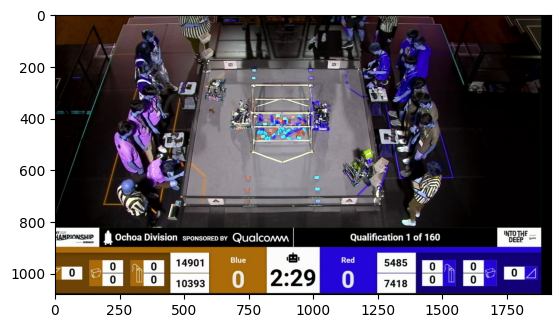

In [48]:
#seek(cap, 47, 32)
seek(cap, 50, 4)
succ, frame = cap.read()
print(succ)
plt.imshow(frame)

In [74]:
print(cap.get(cv2.CAP_PROP_POS_MSEC))

2871999.0000000005


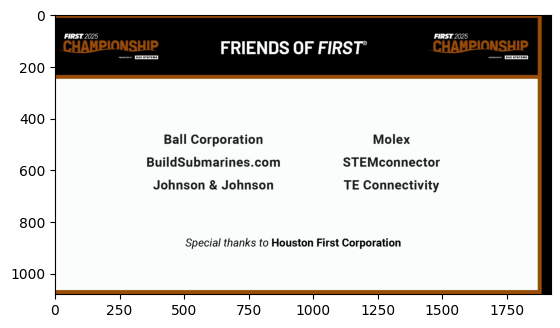

In [17]:
plt.imshow(frame)

In [61]:
(47 * 60 + 30) * 1000

2850000

In [84]:
cap.set(cv2.CAP_PROP_POS_FRAMES, 85500)

[NULL @ 0x5a5f9cd6d900] chroma_log2_weight_denom 11 is out of range
[NULL @ 0x5a5f9cd6d900] illegal reordering_of_pic_nums_idc 15
[NULL @ 0x5a5f9cd6d900] luma_log2_weight_denom 32 is out of range
[NULL @ 0x5a5f9cd6d900] chroma_log2_weight_denom 17 is out of range
[NULL @ 0x5a5f9cd6d900] illegal memory management control operation 30
[h264 @ 0x5a5fa3646980] Missing reference picture, default is 0
[h264 @ 0x5a5fa3646980] decode_slice_header error
[h264 @ 0x5a5f9a6cd500] illegal modification_of_pic_nums_idc 31
[h264 @ 0x5a5f9a6cd500] decode_slice_header error
[h264 @ 0x5a5f9a6cd500] no frame!
[NULL @ 0x5a5f9cd6d900] reference count 2 overflow
[h264 @ 0x5a5f9706ca00] reference overflow 16 > 15 or 11 > 15
[h264 @ 0x5a5f9706ca00] decode_slice_header error
[h264 @ 0x5a5f9706ca00] no frame!
[h264 @ 0x5a5fa35e62c0] reference count overflow
[h264 @ 0x5a5fa35e62c0] decode_slice_header error
[h264 @ 0x5a5fa35e62c0] no frame!
[h264 @ 0x5a5fa078cac0] reference overflow 1 > 15 or 34 > 15
[h264 @ 0x5a

True

True

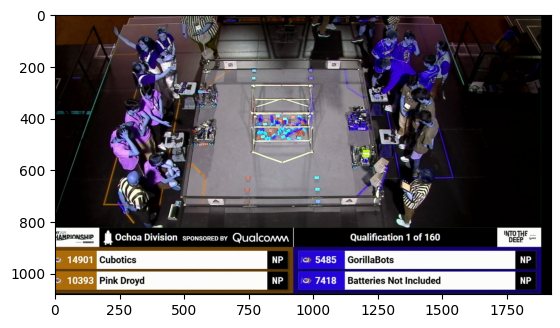

In [85]:
succ, frame = cap.read()
plt.imshow(frame)
succ

In [79]:
match_frame = frame

In [65]:
params = consts.ScaledParams(1920, 1080)

In [43]:
logo_matcher = matchers.ITDLogoMatcher(params)
basket_matcher = matchers.ITDRedBasketMatcher(params)

In [15]:
has_logo, match_tlbr = logo_matcher.match(frame)
match_tlbr

((1708, 825), (1878, 899))

In [50]:
match_display, match_is_top = util.get_match_display(frame, match_tlbr, params)
match_is_top

False

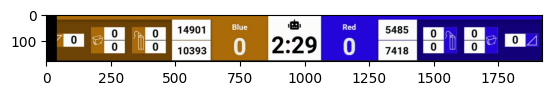

In [51]:
plt.imshow(match_display)

In [52]:
util.match_is_preview(match_display, basket_matcher, params)

False

In [59]:
timestamp, other = util.extract_match_time(match_display, params)
timestamp

'2:29'

In [61]:
util.are_colors_flipped(match_display, params)

False

In [62]:
cap.get(cv2.CAP_PROP_POS_MSEC) / 1000

3003.9990000000003

In [66]:
match_name, _ = util.extract_match_name(frame, match_tlbr, params)
match_name

'Qualification 1 of 160'

In [67]:
display_data = util.extract_display_data(match_display, params)
display_data

DisplayData(display_flipped=False, red_teams=('5485', '7418'), blue_teams=('14901', '10393'))

In [71]:
results = pass1.run("/home/guinea/remote/cmptx_ochoa_d1_1.ts", seek=85200)

[NULL @ 0x5897261c4d80] chroma_log2_weight_denom 11 is out of range
[NULL @ 0x5897261c4d80] illegal reordering_of_pic_nums_idc 15
[NULL @ 0x5897261c4d80] luma_log2_weight_denom 32 is out of range
[NULL @ 0x5897261c4d80] chroma_log2_weight_denom 16 is out of range
[h264 @ 0x58972c0aa480] reference count overflow
[h264 @ 0x58972c0aa480] decode_slice_header error
[h264 @ 0x58972c0aa480] no frame!
[h264 @ 0x58972dc95900] deblocking filter parameters 0 -9 out of range
[h264 @ 0x58972dc95900] decode_slice_header error
[h264 @ 0x58972dc95900] no frame!
[h264 @ 0x58972dca8d40] reference count overflow
[h264 @ 0x58972dca8d40] decode_slice_header error
[h264 @ 0x58972dca8d40] no frame!
[NULL @ 0x5897261c4d80] reference count 2 overflow
[h264 @ 0x58972dca5780] reference overflow 16 > 15 or 9 > 15
[h264 @ 0x58972dca5780] decode_slice_header error
[h264 @ 0x58972dca5780] no frame!
[h264 @ 0x58972dd94bc0] reference count overflow
[h264 @ 0x58972dd94bc0] decode_slice_header error
[h264 @ 0x58972dd94b

In [74]:
pprint.pprint(results)

Pass1EventData(fps=30,
               width=1920,
               height=1080,
               matches=[Pass1EventMatch(name='Qualification 1 of 160',
                                        top=False,
                                        frame_idx=89430,
                                        video_sec=3003.565,
                                        match_ts=149,
                                        display_data=DisplayData(display_flipped=False,
                                                                 red_teams=('5485',
                                                                            '7418'),
                                                                 blue_teams=('14901',
                                                                             '10393')),
                                        is_replay=False),
                        Pass1EventMatch(name='Qualification 1 of 160',
                                        top=False,
                  

In [187]:
p2 = pass2.combine_matches(results, seed=None)
p2

[Pass2EventMatch(name='Qualification 1 of 160', start_ts=np.float64(2998.5649999999996), end_ts=np.float64(3165.5649999999996), red_teams=('5485', '7418'), blue_teams=('14901', '10393'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 2 of 160', start_ts=np.float64(3379.5650000000005), end_ts=np.float64(3546.5650000000005), red_teams=('7149', '21311'), blue_teams=('3954', '23638'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 3 of 160', start_ts=np.float64(3712.5650000000005), end_ts=np.float64(3879.5650000000005), red_teams=('24253', '18240'), blue_teams=('20092', '16700'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 4 of 160', start_ts=np.float64(4052.565000000001), end_ts=np.float64(4219.5650000000005), red_teams=('24950', '18844'), blue_teams=('4785', '19705'), is_replay=False, top=False, colors_flipped=False),
 Pass2EventMatch(name='Qualification 5 of 160'

In [194]:
[f"{p.name} | {int(p.start_ts // 60):02}:{int(p.start_ts % 60):02} -> {int(p.end_ts // 60):02}:{int(p.end_ts%60):02}" for p in p2]

['Qualification 1 of 160 | 49:58 -> 52:45',
 'Qualification 2 of 160 | 56:19 -> 59:06',
 'Qualification 3 of 160 | 61:52 -> 64:39',
 'Qualification 4 of 160 | 67:32 -> 70:19',
 'Qualification 5 of 160 | 73:51 -> 76:38',
 'Qualification 6 of 160 | 78:50 -> 81:37',
 'Qualification 7 of 160 | 84:06 -> 86:53',
 'Qualification 8 of 160 | 90:21 -> 93:08',
 'Qualification 9 of 160 | 95:49 -> 98:36',
 'Qualification 10 of 160 | 101:08 -> 103:55',
 'Qualification 11 of 160 | 109:30 -> 112:17',
 'Qualification 12 of 160 | 114:23 -> 117:10',
 'Qualification 13 of 160 | 121:08 -> 123:55',
 'Qualification 14 of 160 | 127:35 -> 130:22',
 'Qualification 15 of 160 | 132:51 -> 135:38',
 'Qualification 16 of 160 | 137:56 -> 140:43']

In [126]:
3000 / 60

50.0

In [189]:
(lambda x: (x // 60, x % 60))(3379)

(56, 19)